# Benchmark Results

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Load results

In [8]:
OUTPUT_DIR = Path("output")

rows = []
for path in sorted(OUTPUT_DIR.glob("*.json")):
    data = json.loads(path.read_text())
    if data.get("n_samples") != 1000:
        print(f"Skipping {path.name} (n_samples={data.get('n_samples')})")
        continue
    rows.append(data)

df = pd.DataFrame(rows)
df["total_time"] = df["startup_time"] + df["run_time"]
df.sort_values("total_time", inplace=True)
df

,lib_name,model,n_samples,batch_size,tensor_parallelism,pipeline_parallelism,startup_time,run_time,n_activation_vectors,average_len,d_model,total_time
5,pure-vllm-tp4,facebook/opt-30b,1000,NaN,4,1,61.377841,43.256692,0,0.000,0,104.634533
9,vllm-lens-tp4,facebook/opt-30b,1000,NaN,4,1,67.988866,78.387717,1000,345.813,7168,146.376583
6,pure-vllm,facebook/opt-30b,1000,NaN,1,1,24.280523,225.793034,0,0.000,0,250.073557
10,vllm-lens,facebook/opt-30b,1000,NaN,1,1,33.107433,274.039894,1000,328.125,7168,307.147328
4,pure-vllm-llama405b-tp16,meta-llama/Meta-Llama-3.1-405B-Instruct,1000,NaN,16,1,285.497687,426.492498,0,0.000,0,711.990185
8,vllm-lens-llama405b-tp16,meta-llama/Meta-Llama-3.1-405B-Instruct,1000,NaN,16,1,283.024184,539.615981,1000,573.674,16384,822.640165
3,pure-vllm-glm5-tp16,zai-org/GLM-5-FP8,1000,NaN,16,1,980.910440,744.036837,0,0.000,0,1724.947277
7,vllm-lens-glm5-tp16,zai-org/GLM-5-FP8,1000,NaN,16,1,945.059894,854.064415,1000,909.586,6144,1799.124309
0,HF-Transformers,facebook/opt-30b,1000,16.0,1,1,40.007041,2447.824302,1000,1021.536,7168,2487.831343
2,nnsight-vllm,facebook/opt-30b,1000,NaN,1,1,46.024251,3218.199941,1,318545.000,7168,3264.224192


## Stacked bar chart — TP=1, PP=1

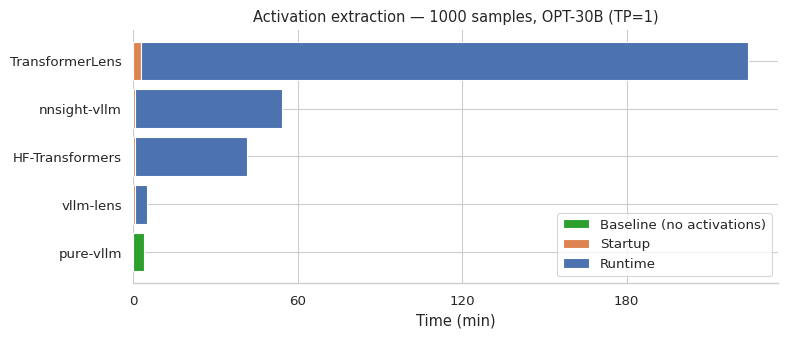

In [19]:
from matplotlib.ticker import MultipleLocator

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

tp1 = df[(df["tensor_parallelism"] == 1) & (df["pipeline_parallelism"] == 1)].copy()
tp1_no_vllm = tp1[tp1["lib_name"] != "pure-vllm"].sort_values("run_time", ascending=True)
tp1_vllm = tp1[tp1["lib_name"] == "pure-vllm"]

order = tp1_vllm["lib_name"].tolist() + tp1_no_vllm["lib_name"].tolist()

fig, ax = plt.subplots(figsize=(8, max(3, len(tp1) * 0.7)))

ax.barh(tp1_vllm["lib_name"], tp1_vllm["run_time"] / 60, label="Baseline (no activations)", color="#2ca02c")
ax.barh(tp1_no_vllm["lib_name"], tp1_no_vllm["startup_time"] / 60, label="Startup", color=sns.color_palette()[1])
ax.barh(tp1_no_vllm["lib_name"], tp1_no_vllm["run_time"] / 60, left=tp1_no_vllm["startup_time"].values / 60, label="Runtime", color=sns.color_palette()[0])

ax.set_yticklabels([])
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)

ax.xaxis.set_major_locator(MultipleLocator(60))
ax.set_xlabel("Time (min)")
ax.set_title("Activation extraction — 1000 samples, OPT-30B (TP=1)")
ax.legend(loc="lower right")
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [17]:
tp1["lib_name"].unique()

array(['pure-vllm', 'vllm-lens', 'HF-Transformers', 'nnsight-vllm',
       'TransformerLens'], dtype=object)